# Нейросетевая классификация текстов

Ваша задача - обучить модель, которая получит на тестовой части качество по метрике  `accuracy` более `0.9`.

## Импорт необходимых библиотек

In [1]:
!pip install -qU datasets
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import Dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk
from collections import Counter
from typing import List
import string
import seaborn
seaborn.set(palette='summer')
nltk.download('punkt')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

In [3]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/tweets_lemm_train.csv")
df.head()

,text,positive,lemm_text
0,"@first_timee хоть я и школота, но поверь, у на...",1,хоть я и школотый но поверь у мы то же самый о...
1,"Да, все-таки он немного похож на него. Но мой ...",1,да весь таки он немного похожий на он но мой м...
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,ну ты идиотка я испугаться за ты
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,кто то в угол сидеть и погибать от голод а мы ...
4,@irina_dyshkant Вот что значит страшилка :D\r\...,1,вот что значит страшилка но блин посмотреть ве...


In [4]:
dataset = Dataset.from_pandas(df[['text', 'positive']])
dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'positive'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['text', 'positive'],
        num_rows: 1000
    })
})

## Preprocess

Bыполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [5]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    processed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(processed_text):
        words[word] += 1

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 0 # Перевел все слова в токены

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/4000 [00:00<?, ?it/s]

Размер словаря: 16852


In [6]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "positive": self.data[idx]['positive']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    positive = torch.LongTensor([x['positive'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'positive': positive
    }

    return new_batch

In [7]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idxs = np.random.choice(np.arange(len(dataset['test'])), 500)
eval_dataset = WordDataset(dataset['test'].select(idxs))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [8]:
# Сильное несоответсвие данных!
# При counter_threshold = 25 -> ([('<unk>', 3469)], 154, 6802) !!!

counter = Counter()
for i in eval_dataset:
    text = [ind2word[ind] for ind in i['text']]
    for char in text:
        counter[char] += 1
counter.most_common(1), len(counter), sum([i for _, i in counter.items()])

([('<unk>', 1704)], 1168, 6802)

## Ход работы


1. Запуск базовой модели.

2. Проведение экспериментов по улучшению модели\
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.\
Обратите внимание, что главное правило проведения экспериментов - необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.\
Вот несколько идей экспериментов:
  * **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
  * **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
  * **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
  * **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

3. Получение высокого качества\
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`.

In [9]:
# Иная сборка датасета

df = pd.read_csv("https://code.s3.yandex.net/datasets/tweets_lemm_train.csv")
df.head()

,text,positive,lemm_text
0,"@first_timee хоть я и школота, но поверь, у на...",1,хоть я и школотый но поверь у мы то же самый о...
1,"Да, все-таки он немного похож на него. Но мой ...",1,да весь таки он немного похожий на он но мой м...
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,ну ты идиотка я испугаться за ты
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,кто то в угол сидеть и погибать от голод а мы ...
4,@irina_dyshkant Вот что значит страшилка :D\r\...,1,вот что значит страшилка но блин посмотреть ве...


In [10]:
dataset = Dataset.from_pandas(df[['lemm_text', 'positive']])
dataset = dataset.rename_columns({'lemm_text': 'text'})
dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'positive'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['text', 'positive'],
        num_rows: 1000
    })
})

In [11]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    processed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(processed_text):
        words[word] += 1

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])

for char, _ in words.items():
    if char not in stopwords:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/4000 [00:00<?, ?it/s]

Размер словаря: 8421


In [13]:
train_dataset = WordDataset(dataset['train'])
eval_dataset = WordDataset(dataset['test'])

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [14]:
# Стало лучше

counter = Counter()
for i in eval_dataset:
    text = [ind2word[ind] for ind in i['text']]
    for char in text:
        counter[char] += 1
counter.most_common(1), len(counter), sum([i for _, i in counter.items()])

([('<unk>', 5918)], 1879, 12844)

## Базовая модель

In [15]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 2,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [16]:
def evaluate(model) -> float:
    """
    Calculate accuracy on validation dataloader.
    """
    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['positive'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

In [17]:
model = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [18]:
torch.manual_seed(0)

num_epoch = 5
eval_steps = len(train_dataloader) // 2

losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLM(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['positive'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/125 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/125 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/125 [00:00<?, ?it/s]

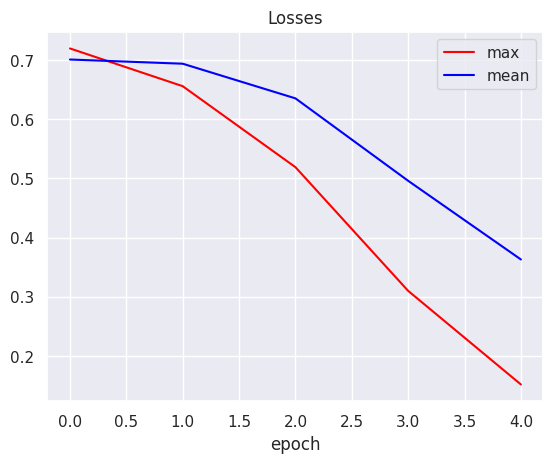

In [19]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

plt.title('Losses')
plt.xlabel("epoch")
plt.legend()
plt.show()

Лучшая accuracy для подхода max: 60.50
Лучшая accuracy для подхода mean: 61.60


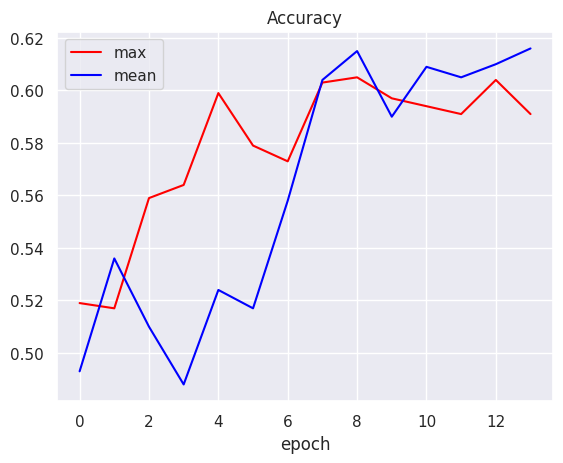

In [20]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()

## <ваш код>

In [21]:
class MyModelGru(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, emd_dim: int,
        num_classes: int = 2, aggregation_type: str = 'max',
        num_layers: int = 1, dropout_rate: float = 0.1,
        use_last_token: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emd_dim)
        self.rnn = nn.GRU(emd_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        if use_last_token:
            self.linear = nn.Linear(hidden_dim*2, hidden_dim)
        else:
            self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout_rate)

        self.aggregation_type = aggregation_type
        self.use_last_token = use_last_token

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        if self.use_last_token:
            last_token_emb = output[:, -1, :]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        if self.use_last_token:
            output = torch.cat([output, last_token_emb], dim=1)

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [22]:
def train_and_plot(model, num_epoch=5):

    losses = []
    acc = []

    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in tqdm(range(num_epoch), desc='Training progress'):
        epoch_losses = []
        model.train()
        for batch in train_dataloader:
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['positive'])
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        model.eval()
        acc.append(evaluate(model))

    plt.figure(figsize=[12, 5])
    plt.subplot(1, 2, 1)
    plt.title('Losses')
    plt.xlabel('epoch')
    plt.plot(losses)
    plt.subplot(1, 2, 2)
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.plot(acc)
    plt.show()

    return losses, acc

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

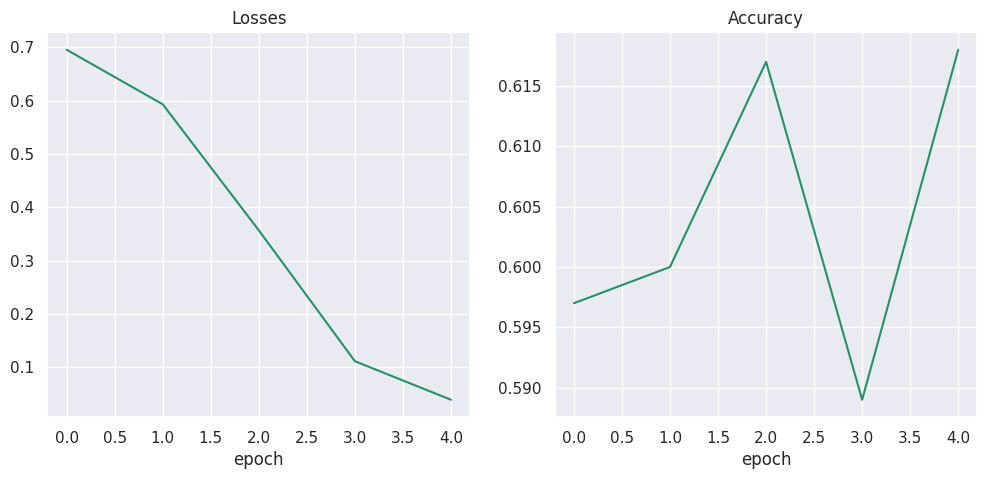

0.6180000305175781

In [23]:
torch.manual_seed(0)
model_exp_1 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=256).to(device)
loss_exp_1, acc_exp_1 = train_and_plot(model_exp_1)
evaluate(model_exp_1)

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

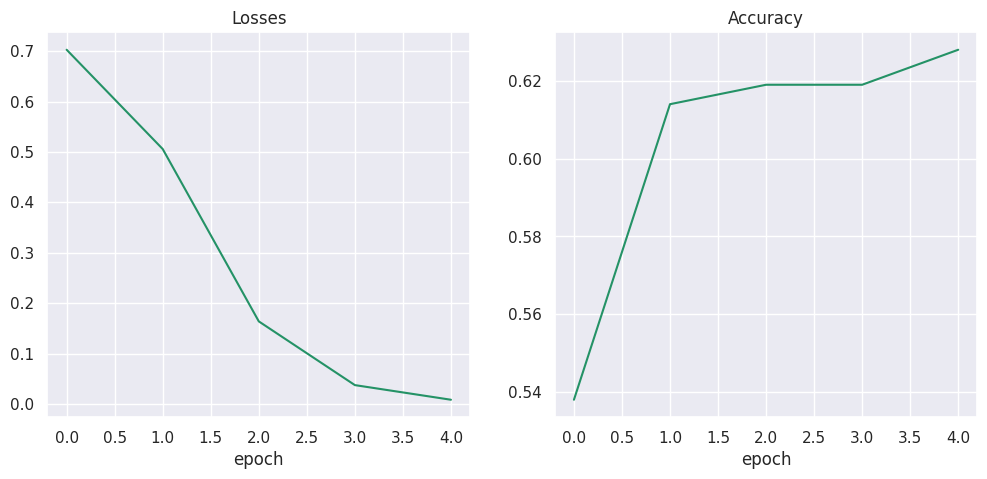

0.628000020980835

In [24]:
torch.manual_seed(0)
model_exp_2 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024).to(device)
loss_exp_2, acc_exp_2 = train_and_plot(model_exp_2)
evaluate(model_exp_2)

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

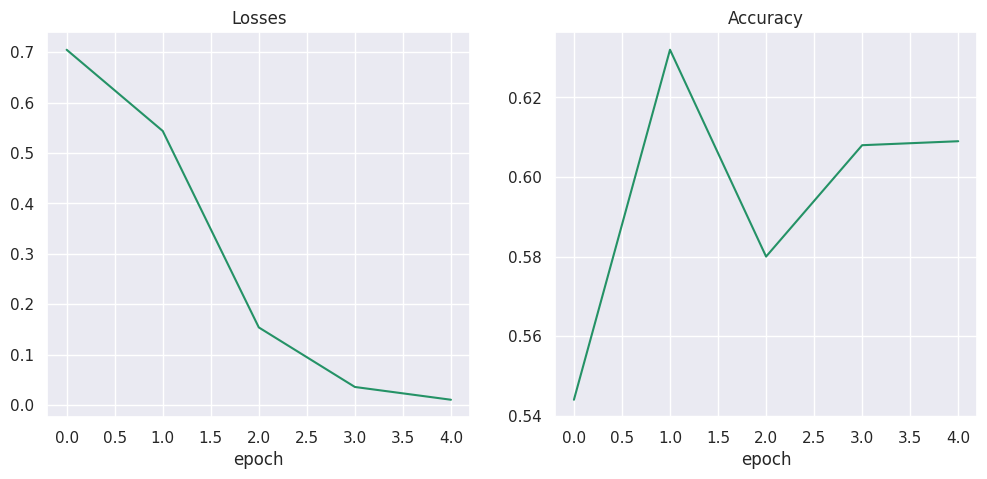

0.609000027179718

In [25]:
torch.manual_seed(0)
model_exp_3 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024,
                         use_last_token=True).to(device)
loss_exp_3, acc_exp_3 = train_and_plot(model_exp_3)
evaluate(model_exp_3)

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

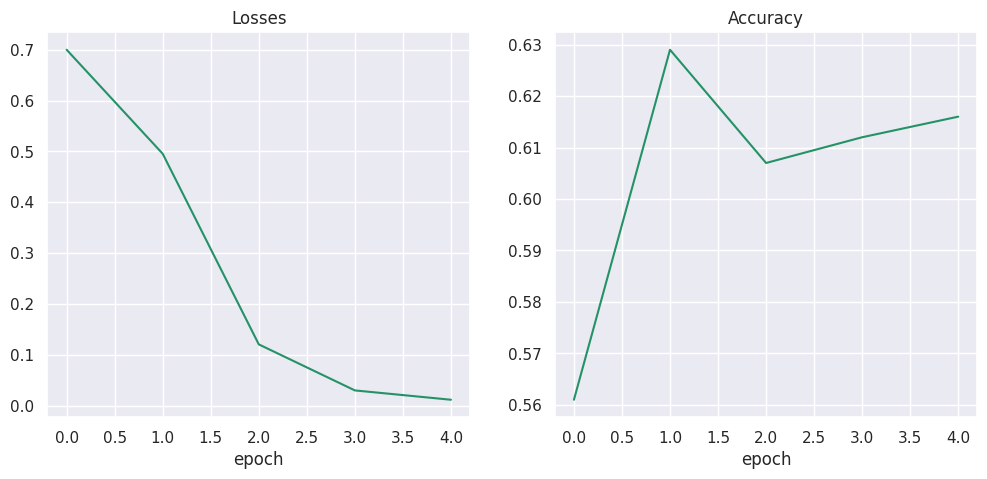

0.6160000562667847

In [26]:
torch.manual_seed(0)
model_exp_4 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024,
                        use_last_token=True, aggregation_type='mean').to(device)
loss_exp_4, acc_exp_4 = train_and_plot(model_exp_4)
evaluate(model_exp_4)

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

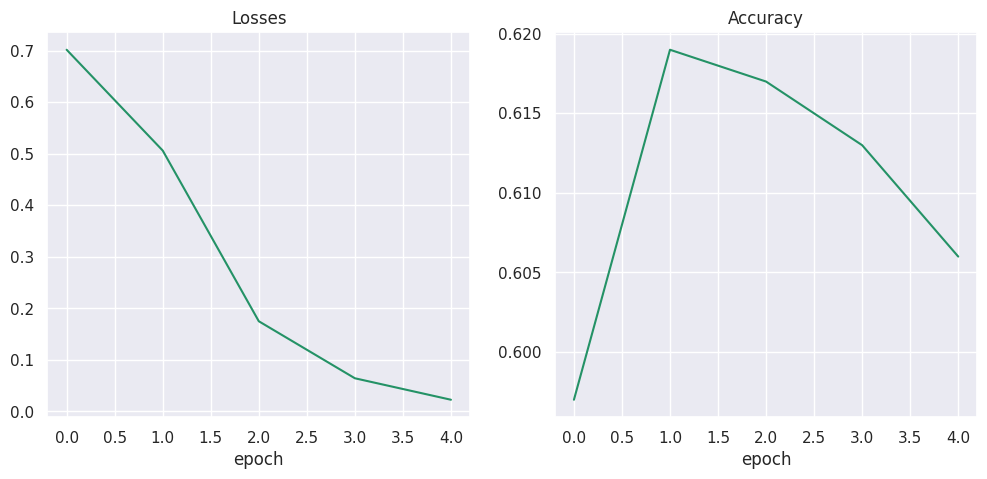

0.6060000061988831

In [27]:
torch.manual_seed(0)
model_exp_5 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024,
                        use_last_token=True, aggregation_type='mean',
                        num_layers=2).to(device)
loss_exp_5, acc_exp_5 = train_and_plot(model_exp_5)
evaluate(model_exp_5)

Training progress:   0%|          | 0/5 [00:00<?, ?it/s]

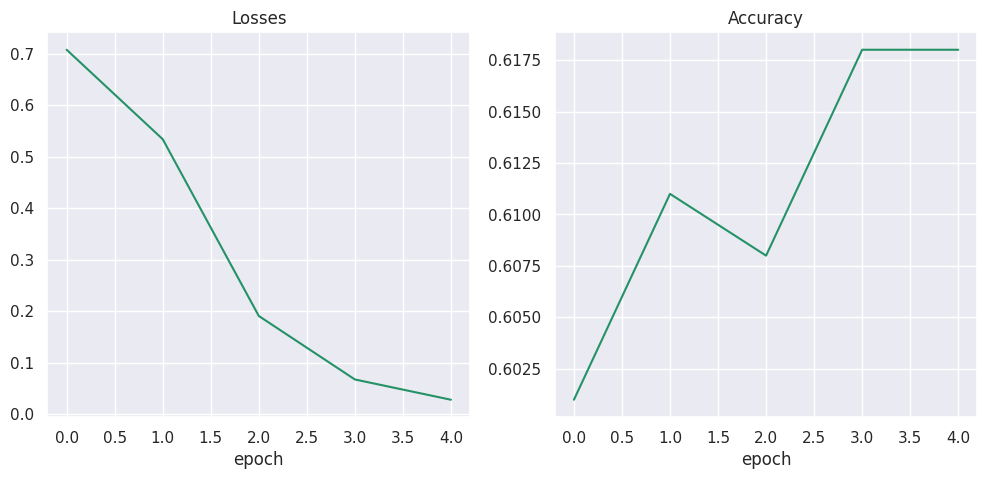

0.6180000305175781

In [28]:
torch.manual_seed(0)
model_exp_6 = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024,
                        use_last_token=True, aggregation_type='mean',
                        num_layers=2, dropout_rate=0.2).to(device)
loss_exp_6, acc_exp_6 = train_and_plot(model_exp_6)
evaluate(model_exp_6)

Training progress:   0%|          | 0/10 [00:00<?, ?it/s]

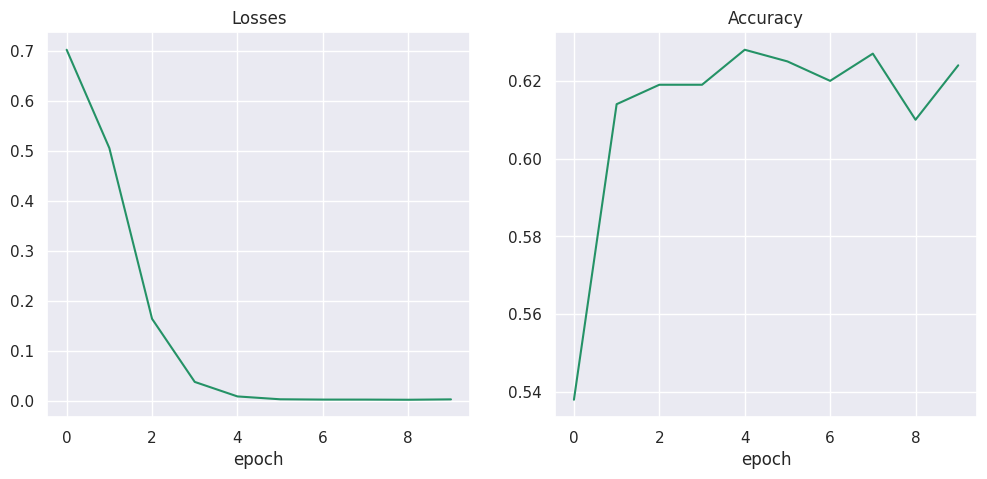

0.6240000128746033

In [30]:
torch.manual_seed(0)
model_exp_eos = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=1024).to(device)
loss_exp_eos, acc_exp_eos = train_and_plot(model_exp_eos, num_epoch=10)
evaluate(model_exp_eos)

Training progress:   0%|          | 0/20 [00:00<?, ?it/s]

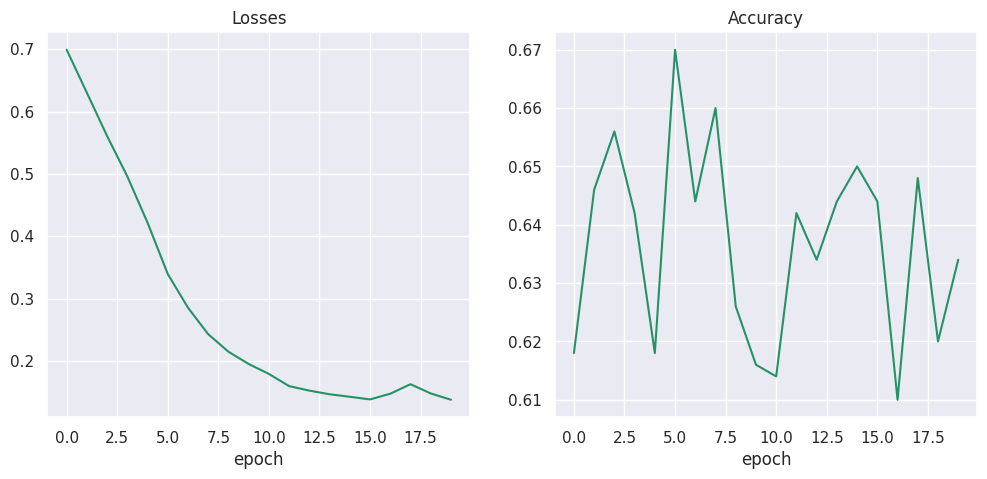

0.6340000033378601

In [ ]:
# Артефакт перебора параметров на старых датасетах - каким-то образом достигало 0.67
model_exp_ = MyModelGru(hidden_dim=256, vocab_size=len(vocab), emd_dim=512,
                        dropout_rate=0.2,
                        num_layers=2, aggregation_type='mean',
                        use_last_token=True).to(device)
loss_exp_, acc_exp_ = train_and_plot(model_exp_, num_epoch=20)
evaluate(model_exp_)

# Другой метод решения

In [51]:
!pip install transformers >> None
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [47]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

def compute_embeddings(sentences):
    encoded_input = tokenizer(sentences, padding=True, truncation=True, max_length=256, return_tensors='pt').to('cuda')
    with torch.no_grad():
        model_output = model(**encoded_input)
    return mean_pooling(model_output, encoded_input['attention_mask'])

tokenizer = AutoTokenizer.from_pretrained('ai-forever/sbert_large_nlu_ru')
model = AutoModel.from_pretrained('ai-forever/sbert_large_nlu_ru').to('cuda')

In [48]:
df.head()

,text,positive,lemm_text
0,"@first_timee хоть я и школота, но поверь, у на...",1,хоть я и школотый но поверь у мы то же самый о...
1,"Да, все-таки он немного похож на него. Но мой ...",1,да весь таки он немного похожий на он но мой м...
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,ну ты идиотка я испугаться за ты
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,кто то в угол сидеть и погибать от голод а мы ...
4,@irina_dyshkant Вот что значит страшилка :D\r\...,1,вот что значит страшилка но блин посмотреть ве...


In [49]:
texts = df['text']
labels = df['positive'].to_numpy()

embeddings = np.array([compute_embeddings(texts[i])[0].detach().cpu().numpy() for i in tqdm(range(len(texts)))])

  0%|          | 0/5000 [00:00<?, ?it/s]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42)

In [52]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [54]:
y_pred = logreg.predict(X_test)
accuracy_score(y_test, y_pred)

0.949